# Assignment Guidance: Case Study A/B Testing

#1. Menentukan Objective A/B Testing

In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("marketing_AB.csv")

In [ ]:
print("Preview dataset:")
print(df.head())

Preview dataset:
   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  


## Total sales distribution

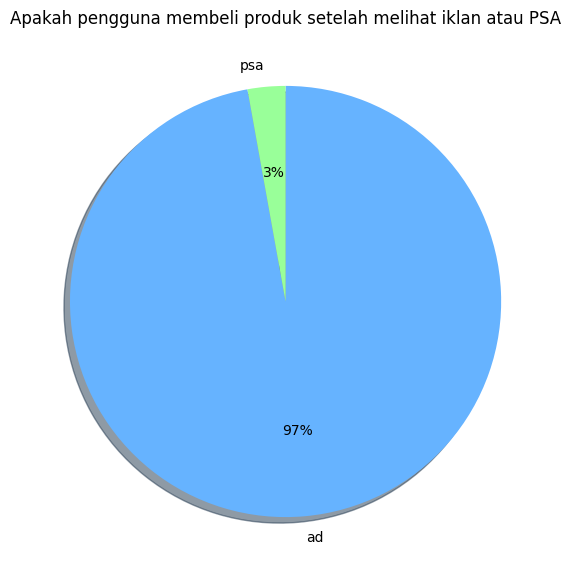

In [ ]:
# Pie chart: distribusi pembelian berdasarkan test group
fig, ax = plt.subplots(figsize=(7,7))
df.groupby("test group")["converted"].sum().plot.pie(
    ax=ax,
    autopct='%1.0f%%',
    startangle=90,
    counterclock=False,
    shadow=True,
    colors=['#66b3ff','#99ff99']
)

ax.set_ylabel("")
ax.set_title("Apakah pengguna membeli produk setelah melihat iklan atau PSA")

plt.show()

Identifikasi Metrik

1. Metrik utama: Conversion Rate (persentase pembelian).
2. Dihitung dari kolom converted (True/False).
3. Dibandingkan berdasarkan test group → Ad (iklan produk) vs PSA (Public Service Announcement).

Objective Spesifik & Terukur

1. Tujuan: Menguji apakah penayangan iklan produk (Ad) meningkatkan konversi dibanding PSA.
2. Objective jelas, terukur, dan dapat diuji dengan data karena tersedia variabel converted.

Dampak Bisnis
1. Jika iklan terbukti meningkatkan konversi, maka:
    - Anggaran pemasaran dapat lebih difokuskan pada penayangan iklan.
    - Strategi pemasaran menjadi lebih efektif.
    - Potensi peningkatan penjualan dan profitabilitas perusahaan.

#2.Menyusun Hipotesis
Buat hipotesis yang dapat diuji secara statistik berdasarkan dataset.
Tentukan hipotesis alternatif (H1) dan hipotesis nol (H0).
Pastikan hipotesis berhubungan langsung dengan metrik yang digunakan dalam dataset.



In [ ]:
ok_ad = df[(df['test group'] == 'ad') & (df['converted'] == 1)].shape[0]
ok_psa = df[(df['test group'] == 'psa') & (df['converted'] == 1)].shape[0]

user_ad = df[df['test group'] == 'ad'].shape[0]
user_psa = df[df['test group'] == 'psa'].shape[0]

success = [ok_ad, ok_psa]
nobs = [user_ad, user_psa]

stat, pval = proportions_ztest(success, nobs)

print("=== Hasil Uji Proporsi Dua Sampel (Z-Test) ===")
print(f"Jumlah konversi (Ad): {ok_ad} dari {user_ad} user")
print(f"Jumlah konversi (PSA): {ok_psa} dari {user_psa} user")
print(f"Statistik Z: {stat:.4f}")
print(f"P-value: {pval:.4f}")

# Interpretasi hasil
alpha = 0.05
if pval < alpha:
    print("Tolak H0: Terdapat perbedaan signifikan proporsi konversi antara Ad dan PSA.")
else:
    print("Gagal tolak H0: Tidak ada bukti cukup adanya perbedaan proporsi konversi antara Ad dan PSA.")


=== Hasil Uji Proporsi Dua Sampel (Z-Test) ===
Jumlah konversi (Ad): 14423 dari 564577 user
Jumlah konversi (PSA): 420 dari 23524 user
Statistik Z: 7.3701
P-value: 0.0000
Tolak H0: Terdapat perbedaan signifikan proporsi konversi antara Ad dan PSA.


#3. Merancang Desain Pengujian Tentukan bagaimana pengujian akan dilakukan menggunakan dataset yang diberikan.



3.1 Pembagian Grup:
Control Group: Pengguna yang tetap menggunakan fitur lama.
Target Group: Pengguna yang mendapatkan fitur baru.


In [ ]:
group_counts = df['test group'].value_counts()

print("=== Jumlah User per Grup ===")
print(group_counts)

=== Jumlah User per Grup ===
test group
ad     564577
psa     23524
Name: count, dtype: int64


Pengguna yg tetap menggunakan fitur lama 23524

Pengguna yg tetap menggunakan fitur baru 564577

3.2 Sample Size: Berikan perkiraan jumlah sampel yang diperlukan.

In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline = 0.10
target   = 0.12
alpha    = 0.05
power    = 0.80

effect_size = proportion_effectsize(baseline, target)

analysis = NormalIndPower()
sample_size = analysis.solve_power(effect_size, power=power, alpha=alpha, ratio=1)

print("=== Estimasi Sample Size A/B Testing ===")
print(f"Baseline CR       : {baseline:.2%}")
print(f"Target CR         : {target:.2%}")
print(f"Alpha (α)         : {alpha}")
print(f"Power (1-β)       : {power}")
print(f"Effect Size (h)   : {effect_size:.4f}")
print(f"Sample Size/Group : {round(sample_size)} user")
print(f"Total Sample      : {round(sample_size)*2} user")


=== Estimasi Sample Size A/B Testing ===
Baseline CR       : 10.00%
Target CR         : 12.00%
Alpha (α)         : 0.05
Power (1-β)       : 0.8
Effect Size (h)   : -0.0640
Sample Size/Group : 3835 user
Total Sample      : 7670 user


3.3 Randomization: Jelaskan bagaimana pengacakan akan dilakukan.


In [ ]:
import numpy as np

df['test group'] = np.random.choice(['control', 'treatment'], size=len(df), replace=True)

group_distribution = df['test group'].value_counts(normalize=True)

print("=== Distribusi Randomisasi User ===")
for group, proportion in group_distribution.items():
    print(f"{group}: {proportion:.2%}")


=== Distribusi Randomisasi User ===
control: 50.05%
treatment: 49.95%


Interpretasi:

  - Distribusi pengguna antara grup Control dan Treatment hampir seimbang
  dengan selisih yang sangat kecil (<0.1%). Hal ini menunjukkan bahwa proses randomisasi sudah berjalan baik, sehingga setiap pengguna memiliki probabilitas yang sama untuk masuk ke salah satu grup.